# Setup

This notebook performs an exploratory data analysis (EDA) of the **CICIDS2017** dataset and builds a baseline anomaly detection model.  

**Goals:**
- Load and consolidate raw CICIDS2017 CSVs.
- Clean and preprocess features into a model-ready matrix `X` and label vector `y`.
- Explore class imbalance and key feature distributions.
- Train and evaluate a baseline model (current implementation: anomaly detection using Isolation Forest and an autoencoder).
- Save figures/metrics to `reports/figures/` for audit and reporting.


In [1]:
import sys
sys.path.insert(0, "..")  # make src/ importable from notebooks/

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
    precision_recall_fscore_support,
)
import plotly.express as px
import umap
import glob
import os
from pathlib import Path

from src.data.cleaning import load_raw, clean

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
mpl.rcParams['font.family'] = 'DejaVu Sans'

## Load Data

We load all CICIDS2017 CSVs from `../cic-ids-eda/data/raw/MachineLearningCVE` via `src.data.cleaning.load_raw`, which attaches a `Meta_source` column indicating the original capture file (= capture day) and concatenates them into a single `combined_df`.

In [3]:
# Load the 8 raw CICIDS2017 CSVs with per-file provenance (Meta_source)
combined_df = load_raw()

print(f"Loaded combined_df with shape {combined_df.shape}")

Loaded combined_df with shape (2830743, 80)


### Initial dataset inspection

We inspect the combined frame to understand schema, dtypes, and basic label structure before cleaning.

In [7]:
combined_df.info();
display(combined_df.columns);

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 80 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [9]:
combined_df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


In [10]:
combined_df[' Label'].unique()

array(['BENIGN', 'DDoS', 'PortScan', 'Bot', 'Infiltration',
       'Web Attack � Brute Force', 'Web Attack � XSS',
       'Web Attack � Sql Injection', 'FTP-Patator', 'SSH-Patator',
       'DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye',
       'Heartbleed'], dtype=object)

## Cleaning & Feature Engineering

Cleaning lives in `src/data/cleaning.py` (shared with `scripts/build_dataset.py`) and applies the v2 policy:

- Strip column names; normalize mojibake web-attack labels (`Web Attack � …` → `Web Attack - …`).
- Drop constant columns and the duplicated `Fwd Header Length.1`.
- Fill genuine `Flow Bytes/s` NaNs (zero-traffic flows) with 0; convert ±inf to NaN and drop those rows explicitly over **both** rate columns.
- Treat `Init_Win_bytes_* = -1` as the sentinel it is ("no TCP window observed", e.g. UDP): keep the rows, add `Has_Init_Win_fwd`/`Has_Init_Win_bwd` indicator features, clamp the sentinel to 0. (The v1 policy dropped these rows — 51% of the dataset, mostly benign.)
- Apply the negative-value filter only to columns where negatives are impossible (excludes IAT and the sentinel columns).
- Remove exact duplicate rows and feature vectors that appear with contradictory labels.

In [12]:
# Apply the v2 cleaning policy (see src/data/cleaning.py and markdown above)
combined_df, manifest = clean(combined_df)

print(f"After cleaning, combined_df shape: {combined_df.shape}")
{k: v for k, v in manifest.items() if k != "label_counts"}

After cleaning, combined_df shape: (2519262, 73)


{'rows_raw': 2830743,
 'flow_bytes_nan_filled': 1358,
 'rows_dropped_inf_rates': 2867,
 'sentinel_flows_kept': 1439672,
 'rows_dropped_negative': 150,
 'rows_dropped_duplicates': 307070,
 'rows_dropped_contradictory_labels': 1394,
 'rows_clean': 2519262,
 'columns': 73}

In [13]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# v2 of the cleaned dataset; v1 (cicids2017_clean.parquet) is kept for
# traceability of earlier reports and models
parquet_path = processed_dir / "cicids2017_clean_v2.parquet"
combined_df.to_parquet(parquet_path, index=False)

print(f"Saved cleaned CICIDS2017 (v2) to {parquet_path}")

Saved cleaned CICIDS2017 (v2) to ../data/processed/cicids2017_clean_v2.parquet


**Data-quality caveat (known CICIDS2017 defects)**

The MachineLearningCVE CSVs have documented flow-construction bugs, mislabeled flows, and
duplicates (Engelen, Rimmer & Joosen 2021, *"Troubleshooting an Intrusion Detection Dataset"*;
Lanvin et al. 2023). Our cleaning removes duplicates and contradictory labels, but residual label
noise bounds the metrics achievable by any model trained on this data — treat absolute scores as
dataset-specific, not deployment estimates.

## Exploratory Data Analysis

We summarize label distributions and inspect a few key features to understand traffic behavior and class imbalance.

In [16]:
for col in combined_df.columns:
    if "Packet" in col:
        print(col)

Total Fwd Packets
Total Backward Packets
Total Length of Fwd Packets
Total Length of Bwd Packets
Fwd Packet Length Max
Fwd Packet Length Min
Fwd Packet Length Mean
Fwd Packet Length Std
Bwd Packet Length Max
Bwd Packet Length Min
Bwd Packet Length Mean
Bwd Packet Length Std
Flow Packets/s
Fwd Packets/s
Bwd Packets/s
Min Packet Length
Max Packet Length
Packet Length Mean
Packet Length Std
Packet Length Variance
Average Packet Size
Subflow Fwd Packets
Subflow Bwd Packets


### Columns containing "Packet"

Columns containing **"Packet"** describe counts and statistics of packets in each flow:

- **Total** – total number of packets in the forward or backward direction.
- **Mean / Max / Min / Std** – descriptive statistics of packet sizes or counts.
- **`/s` suffix** – per-second rates (e.g., packets per second).
- **Subflow** – metrics over sub-divisions of a TCP/UDP flow.

These features are likely important for distinguishing benign vs attack traffic.

In [18]:
df_labels = combined_df[["Label", "Destination Port"]]
df_agg = df_labels.groupby("Label").count().reset_index()

df_agg.rename(columns={"Destination Port": "Count"}, inplace=True)
df_agg["Relative Frequency"] = df_agg["Count"] / df_agg["Count"].sum()
df_agg.sort_values("Count", ascending=False)

,Label,Count,Relative Frequency
0,BENIGN,2094218,0.831282
4,DoS Hulk,172717,0.068559
2,DDoS,128011,0.050813
10,PortScan,90130,0.035776
3,DoS GoldenEye,10286,0.004083
7,FTP-Patator,5931,0.002354
6,DoS slowloris,5384,0.002137
5,DoS Slowhttptest,5228,0.002075
11,SSH-Patator,3219,0.001278
1,Bot,1948,0.000773


**Interpretation – Class Imbalance**

- The dataset is highly imbalanced: **BENIGN** traffic dominates, while some attack types have orders of magnitude fewer samples.
- This imbalance motivates:
  - Using metrics like **precision–recall** instead of accuracy.
  - Considering techniques like stratification, resampling, or anomaly detection models.

### IAT (Inter-Arrival Time) feature family

The CICIDS2017 dataset includes a family of inter-arrival time (IAT) features
(e.g., `Flow IAT Mean`, `Fwd IAT Max`, `Bwd IAT Std`). These are often
heavy-tailed and can take negative or near-zero values depending on how they
were computed. For this reason, we:
- Treat IAT features as a distinct family in EDA.
- Exclude them from the non-negativity filter we apply to other numeric fields.


### Feature Families Overview

This section summarizes the key feature families in CICIDS2017 and why they are relevant for intrusion detection.

**1. Flow metadata**
- Examples: `Destination Port`, `Flow Duration`, `Flow Bytes/s`
- Meaning: High-level properties of each flow (port, duration, throughput).
- Relevance: Well-known ports (22, 80, 443) map to common services; long-lived, high-throughput flows may indicate data transfer or tunneling.

**2. TCP flags**
- Examples: `Fwd PSH Flags`, `Fwd URG Flags`, `FIN Flag Count`, `SYN Flag Count`, `ACK Flag Count`, `RST Flag Count`, `PSH Flag Count`, `URG Flag Count`, `CWE Flag Count`, `ECE Flag Count`
- Meaning: Counters of TCP control flags within the flow.
- Relevance: SYN floods (DoS) → many SYNs; frequent RST → scans or failed connections; rare flags (CWE/ECE) can signal unusual behavior.

**3. Header and segment sizes**
- Examples: `Fwd Header Length`, `Bwd Header Length`, `Avg Fwd Segment Size`, `Avg Bwd Segment Size`, `act_data_pkt_fwd`, `min_seg_size_forward`
- Meaning: Sizes of headers and TCP segments, and counts of packets carrying data.
- Relevance: Very small or crafted segments may indicate scanning/evasion; large segments often correspond to bulk transfers.

**4. Subflow statistics**
- Examples: `Subflow Fwd Bytes`, `Subflow Bwd Bytes`
- Meaning: Byte counts within subflows (TCP/UDP subdivisions).
- Relevance: Can reflect retransmissions, segmentation anomalies, or protocol misuse.

**5. Window sizes**
- Examples: `Init_Win_bytes_forward`, `Init_Win_bytes_backward`
- Meaning: Initial TCP window sizes.
- Relevance: May be used for OS/application fingerprinting; some malware families use unusual window sizes.

**6. Temporal activity (active / idle times)**
- Examples: `Active Mean`, `Active Std`, `Active Max`, `Active Min`, `Idle Mean`, `Idle Std`, `Idle Max`, `Idle Min`
- Meaning: Summary of bursts of activity vs silence within the flow.
- Relevance: Bot/C2 traffic often has regular idle–active patterns; human-driven traffic is more irregular.

**7. Labels and metadata**
- `Label`: Ground-truth class (benign vs specific attack types).
- `Meta_source`: Originating capture/file for the record (dataset split / capture day).


### Total Forward Packets vs Label


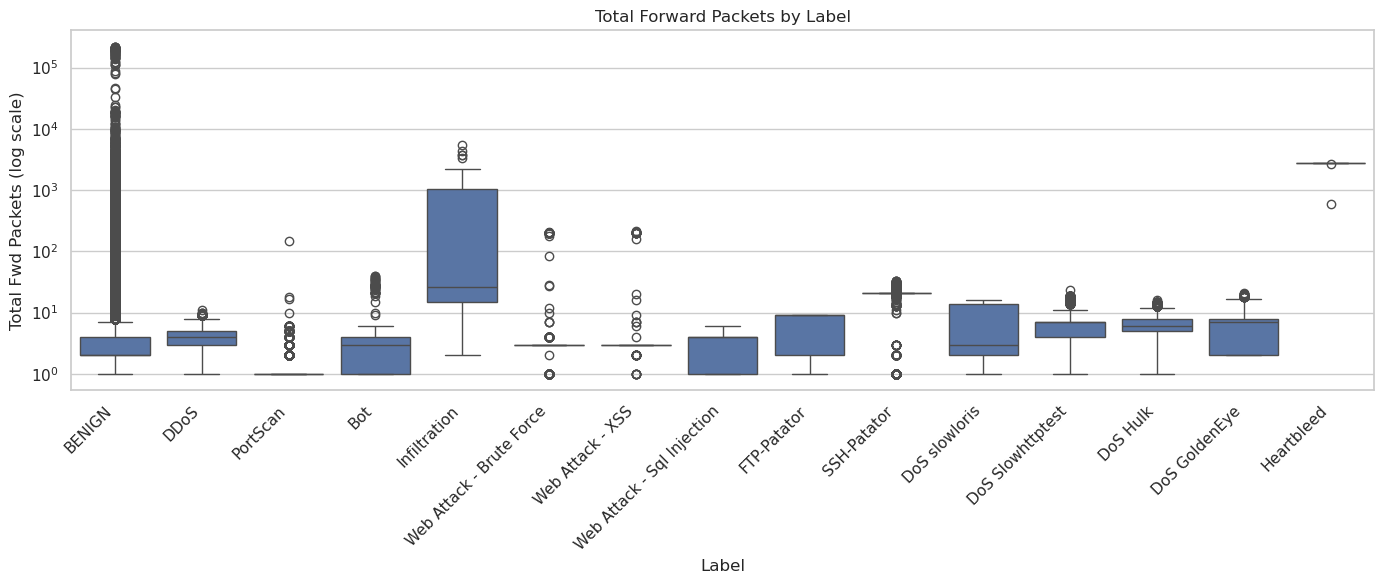

In [23]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=combined_df, x="Label", y="Total Fwd Packets")
plt.xticks(rotation=45, ha="right")
plt.yscale("log")
plt.ylabel("Total Fwd Packets (log scale)")
plt.title("Total Forward Packets by Label")
plt.tight_layout()
plt.show()

**Interpretation**

- Many attack types show heavier tails in **Total Fwd Packets** compared to benign traffic.
- Log scaling reveals that certain attacks (e.g., volumetric DoS) can generate significantly more packets per flow.


### Total Backward Packets vs Label

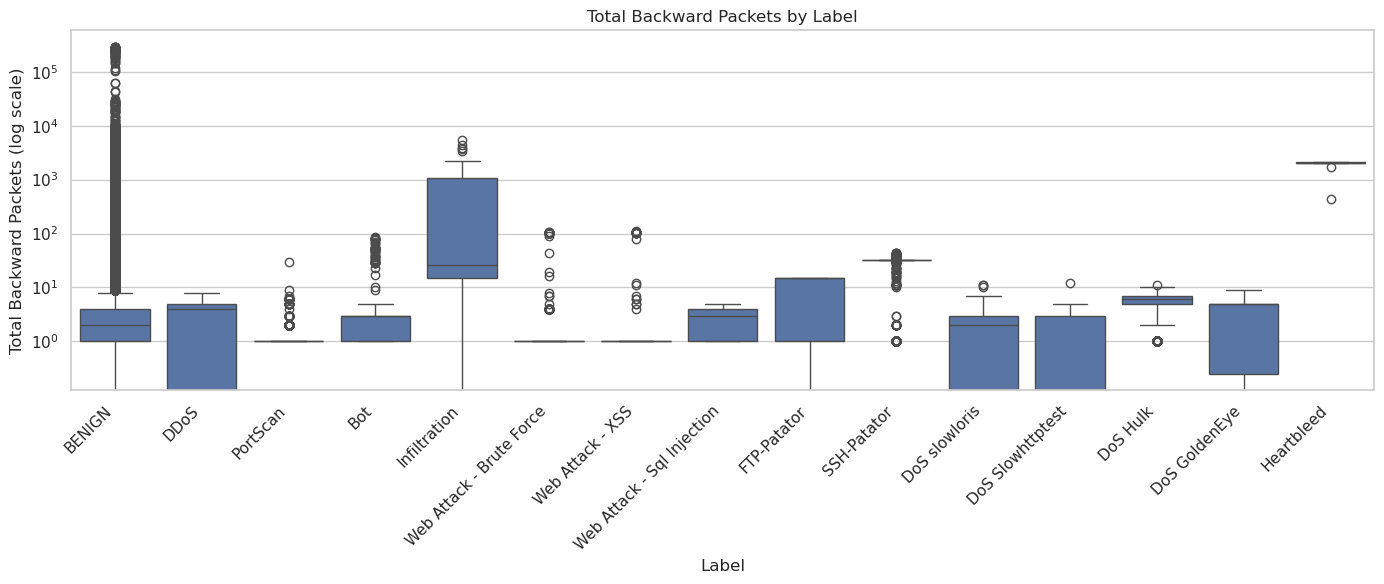

In [26]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=combined_df, x="Label", y="Total Backward Packets")
plt.xticks(rotation=45, ha="right")
plt.yscale("log")
plt.ylabel("Total Backward Packets (log scale)")
plt.title("Total Backward Packets by Label")
plt.tight_layout()
plt.show()

**Interpretation**

- Some attack categories reply with large numbers of backward packets (e.g., scanning or handshake-heavy behavior).
- As with forward packets, the distribution is highly skewed, reinforcing the need for robust scaling before modeling.


### Correlation structure of numeric features


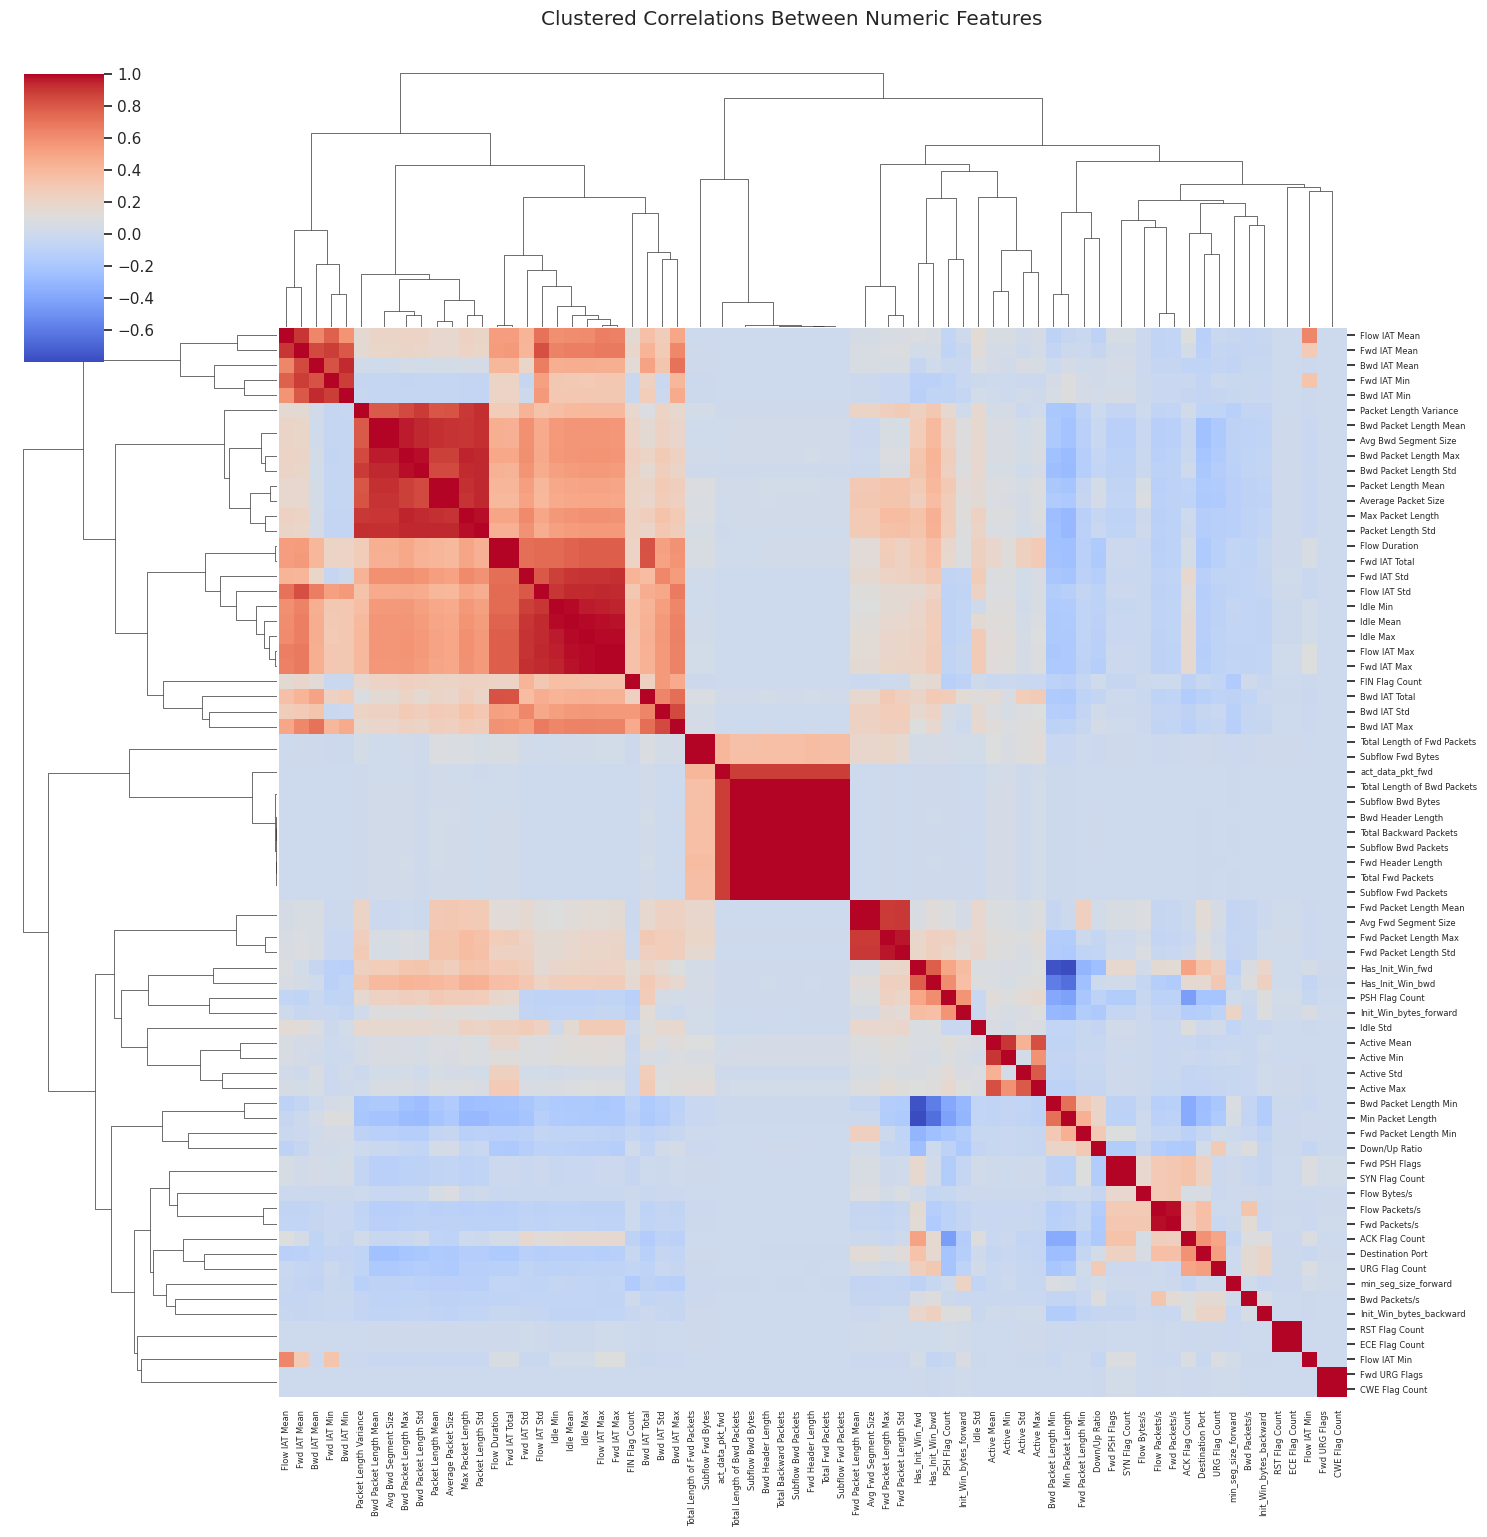

In [29]:
numeric_data = combined_df.select_dtypes(include=[np.number]).corr()

# Hierarchically clustered heatmap: groups correlated feature families together,
# making the block structure readable (a plain 71x71 heatmap is not)
cg = sns.clustermap(
    numeric_data.fillna(0),
    cmap="coolwarm",
    figsize=(16, 16),
    xticklabels=True,
    yticklabels=True,
)
cg.ax_heatmap.tick_params(labelsize=6)
cg.fig.suptitle("Clustered Correlations Between Numeric Features", y=1.02)
plt.show()

**Interpretation**

- Forward/backward variants of similar features (e.g., bytes, packets, IAT statistics) cluster together with high correlation.
- This suggests:
  - Possible dimensionality reduction (PCA/UMAP) before modeling.
  - Regularization or feature selection to avoid multicollinearity issues.


### Sampled visualization (PCA / UMAP / PairPlots)

To keep plots readable, we down-sample each class and visualize structure in lower dimensions.


In [32]:
# Sample up to 2000 rows per label for visualization
sample_df = combined_df.groupby("Label", group_keys=False).apply(
    lambda x: x.sample(min(len(x), 2000), random_state=1)
)

/var/folders/yq/9hnvq27x6lq2z27v61w8bkjh0000gn/T/ipykernel_20535/963035319.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = combined_df.groupby("Label", group_keys=False).apply(


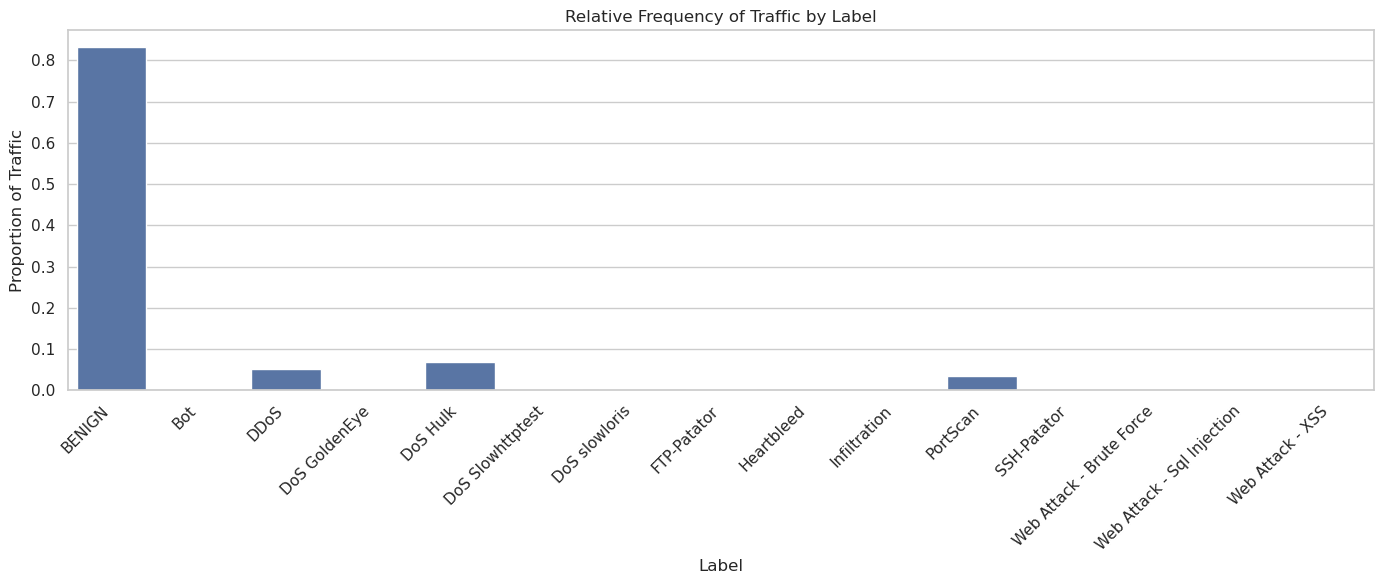

In [35]:
# barplot of relative class frequencies (df_agg computed in the frequency table above)
plt.figure(figsize=(14, 6))
sns.barplot(data=df_agg, x='Label', y='Relative Frequency')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Proportion of Traffic")
plt.title("Relative Frequency of Traffic by Label")
plt.tight_layout()
plt.show()

In [36]:
combined_df['Total Fwd Packets'].describe()

count    2.519262e+06
mean     1.028673e+01
std      7.946621e+02
min      1.000000e+00
25%      2.000000e+00
50%      2.000000e+00
75%      6.000000e+00
max      2.197590e+05
Name: Total Fwd Packets, dtype: float64

>Notice that Infiltration Labels have a higher than begign Total Fwd Packets. 

In [38]:
# Numeric feature set for visualization and modeling (includes the Has_Init_Win_* indicators).
# np.number, not ["int64","float64"]: string dtype matching can miss int64 blocks
# on frames mid-pipeline, silently shrinking the feature set.
numeric_cols = combined_df.select_dtypes(include=[np.number]).columns
assert len(numeric_cols) == 71, f"expected 71 numeric features, got {len(numeric_cols)}"

# Standardize ONCE here; the PCA and UMAP cells below reuse X_sample as-is
X_sample = StandardScaler().fit_transform(sample_df[numeric_cols])
y_sample = sample_df["Label"]

### 2-D PCA Sample

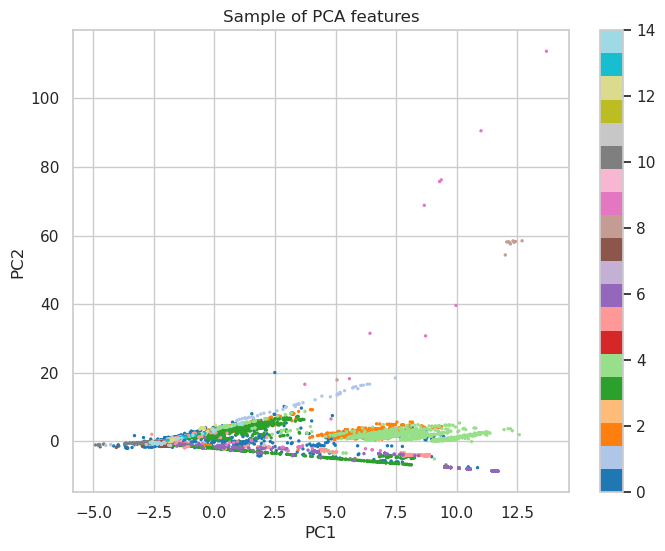

In [40]:
X_pca2 = PCA(n_components=2, random_state=42).fit_transform(X_sample)

plt.figure(figsize=(8,6))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=y_sample.astype('category').cat.codes, cmap='tab20', s=2)
plt.title("Sample of PCA features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()
plt.show()

### **UMAP 2-D**

/opt/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


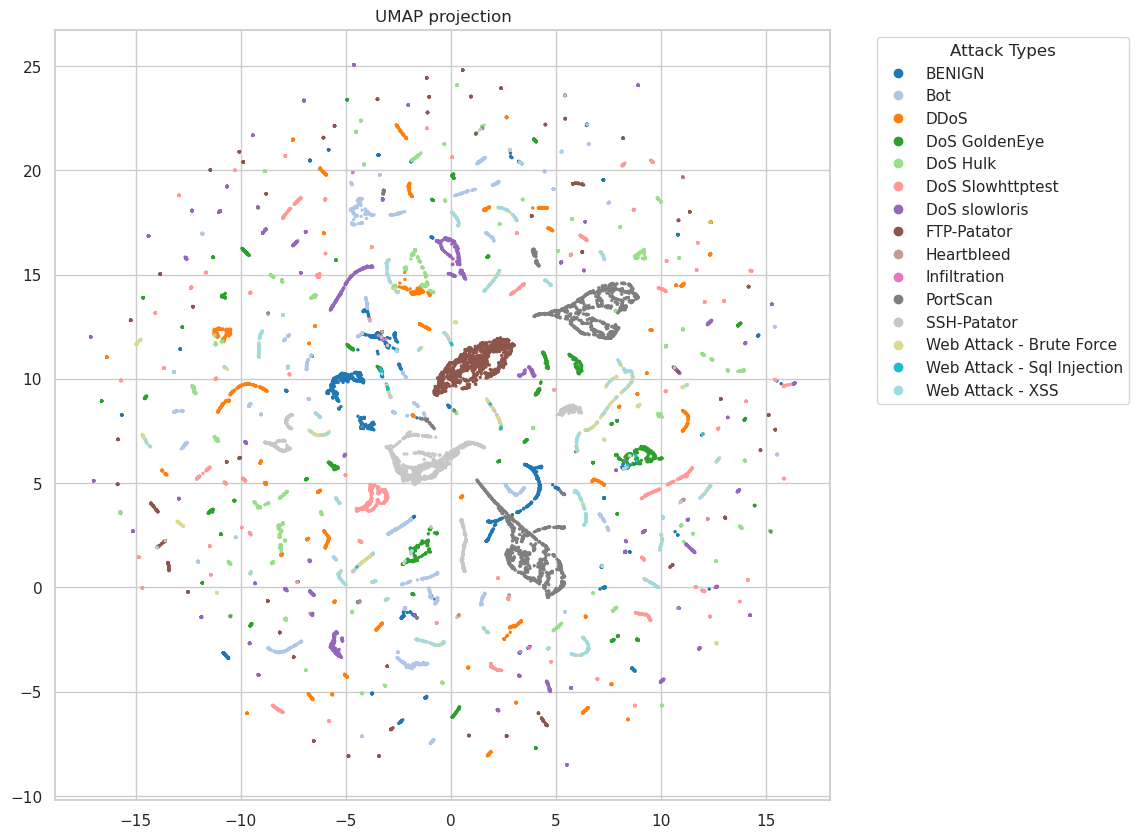

In [42]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_sample)

# 3. Plot UMAP
labels = sample_df['Label'].astype('category')
codes = labels.cat.codes
unique_labels = labels.cat.categories

plt.figure(figsize=(10,10))
scatter = plt.scatter(
    X_umap[:,0], 
    X_umap[:,1], 
    c=codes, 
    cmap='tab20', 
    s=2
)
# Build a legend mapping colors to label names
handles, _ = scatter.legend_elements(num=len(unique_labels))
plt.legend(handles, unique_labels, title="Attack Types", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("UMAP projection")
plt.show()

**Interpretation**

- Even in 2D projections, benign and several attack families occupy overlapping but distinguishable regions.
- Some rare attack types overlap strongly with benign traffic, which is one reason anomaly detection can be challenging.

### PairPlot of selected numeric features


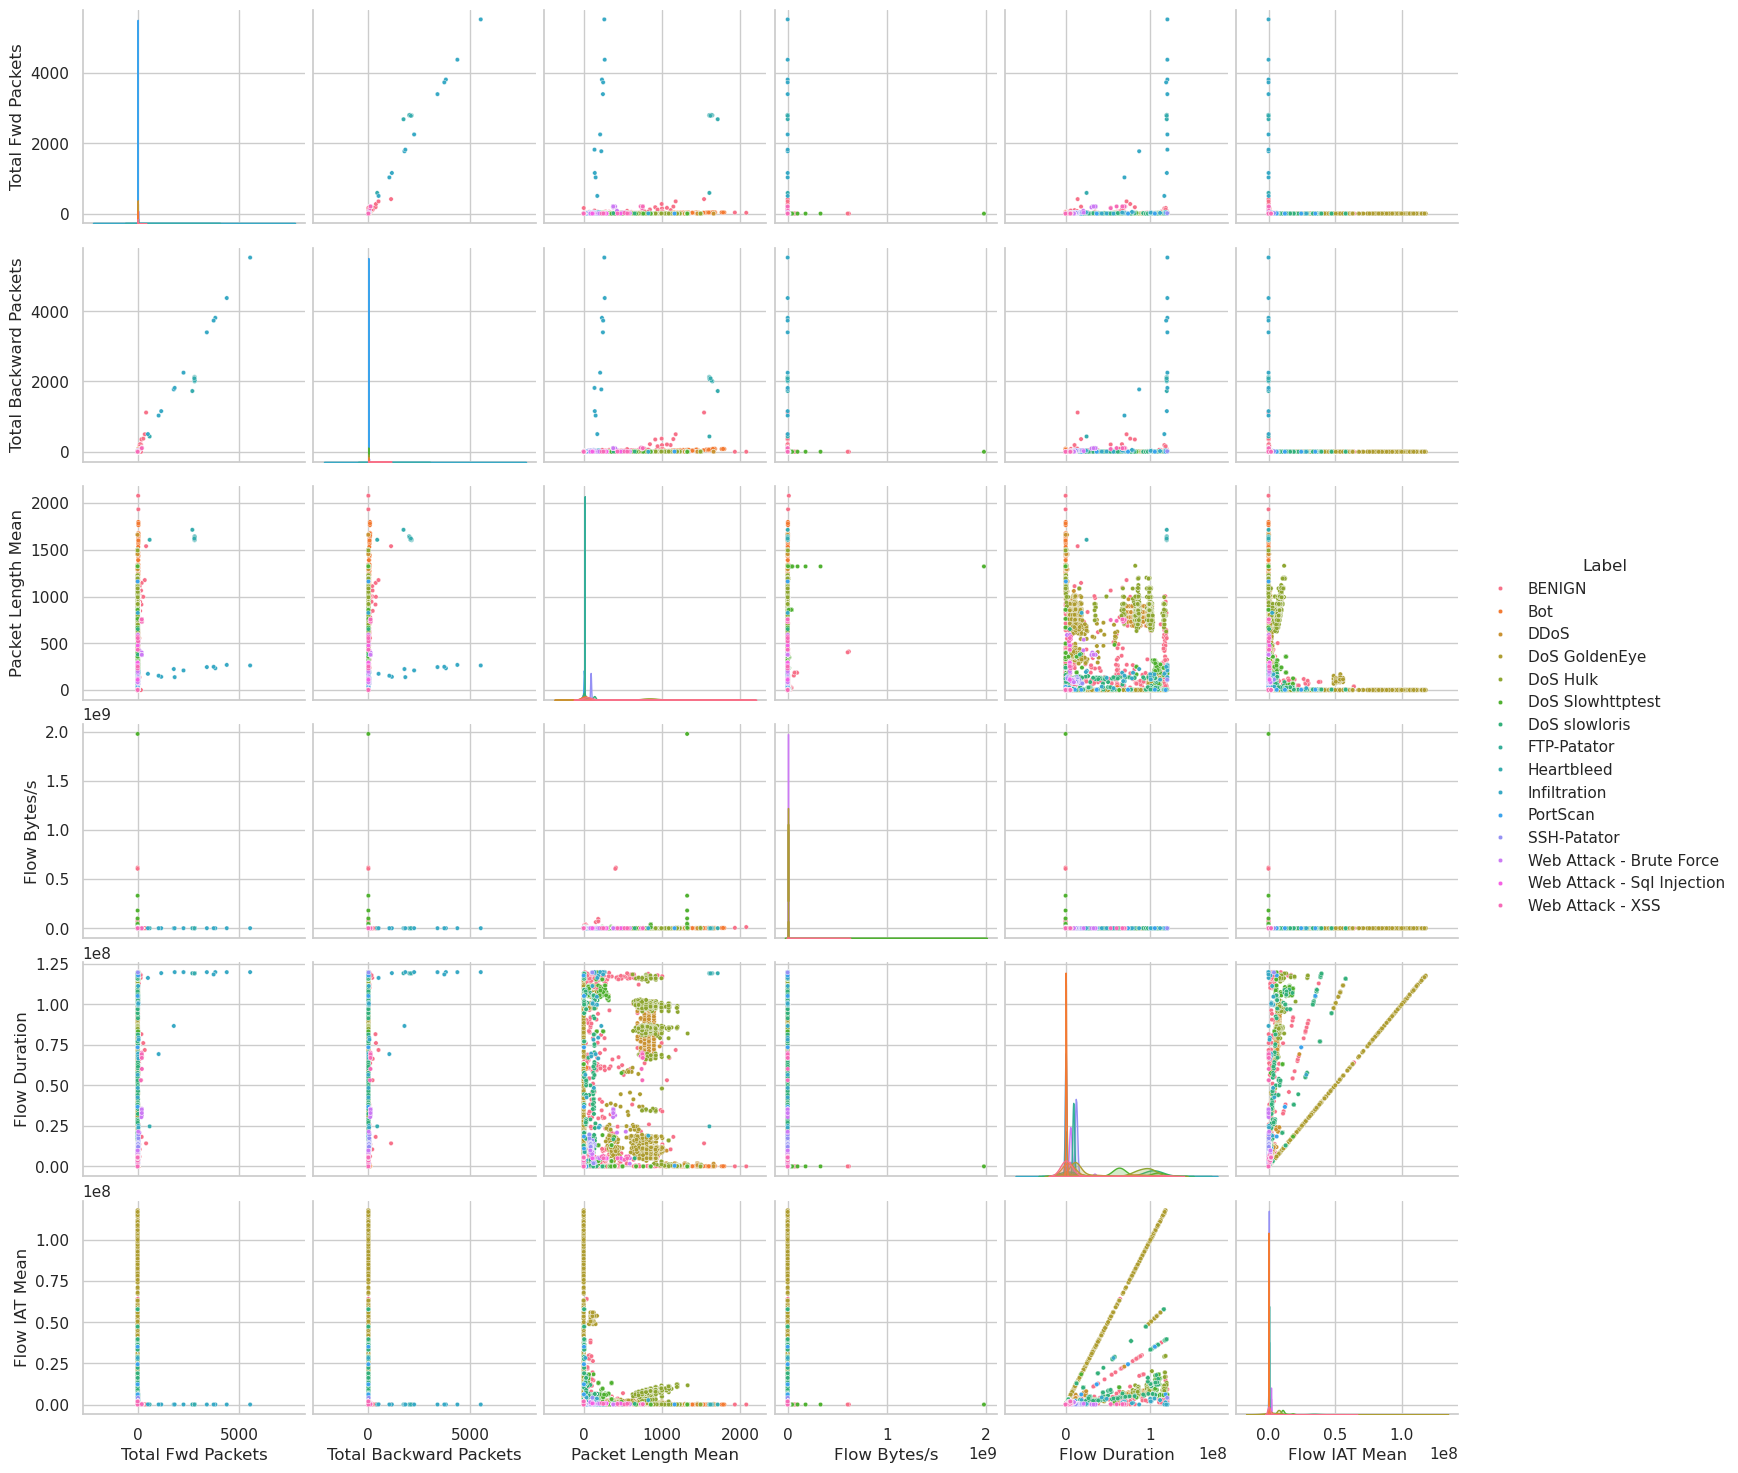

In [45]:
features = [
    "Total Fwd Packets",
    "Total Backward Packets",
    "Packet Length Mean",
    "Flow Bytes/s",
    "Flow Duration",
    "Flow IAT Mean",
]

sns.pairplot(sample_df[features + ["Label"]], hue="Label", plot_kws={"s": 10})

**Interpretation**

- Certain attack families show distinct clusters in feature space (e.g., very high `Flow Bytes/s` or `Flow Duration`).
- Others are closer to benign, motivating more sophisticated models or additional features.


### Baseline model data preparation

We construct a binary label (0 = benign, 1 = attack) and split **before** any resampling, so the
held-out test set keeps the natural benign/attack mix and PR metrics are comparable to a realistic
deployment (the no-skill PR-AUC baseline equals the attack prevalence). The benign class is
downsampled in the **training portion only** for efficiency and reduced imbalance. Scaling lives
inside a `Pipeline`, so cross-validation folds cannot leak scaling statistics into each other.

In [48]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

# 1. Binary label on the full cleaned data
feature_cols = list(numeric_cols)
y_binary = (combined_df["Label"] != "BENIGN").astype(int).values

# 2. Split FIRST (stratified): the test set keeps the natural prevalence
idx_train, idx_test = train_test_split(
    np.arange(len(combined_df)),
    test_size=0.2,
    stratify=y_binary,
    random_state=42,
)

# 3. Downsample benign in the TRAINING portion only
max_benign = 200_000
rng = np.random.RandomState(42)
train_benign = idx_train[y_binary[idx_train] == 0]
train_attack = idx_train[y_binary[idx_train] == 1]
if len(train_benign) > max_benign:
    train_benign = rng.choice(train_benign, size=max_benign, replace=False)
idx_train = np.concatenate([train_benign, train_attack])

X_train = combined_df[feature_cols].iloc[idx_train].to_numpy(dtype=np.float64)
X_test = combined_df[feature_cols].iloc[idx_test].to_numpy(dtype=np.float64)
y_train, y_test = y_binary[idx_train], y_binary[idx_test]
labels_test = combined_df["Label"].values[idx_test]

print(f"Train: {X_train.shape} (attack rate {y_train.mean():.3f} — benign downsampled)")
print(f"Test:  {X_test.shape} (attack rate {y_test.mean():.3f} — natural prevalence)")

Train: (540035, 71) (attack rate 0.630 — benign downsampled)
Test:  (503853, 71) (attack rate 0.169 — natural prevalence)


### Logistic Regression baseline (supervised)

We train a regularized logistic regression inside a `StandardScaler -> LogisticRegression`
pipeline:

- 5-fold StratifiedKFold cross-validation on the training split (PR-AUC per fold; scaler fit
  inside each fold).
- Final fit on the full training set and evaluation on the held-out natural-prevalence test set.
- The no-skill PR-AUC baseline (= attack prevalence) is printed next to the score.

In [50]:
def make_logreg_pipeline():
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=1000,
            n_jobs=-1,
            class_weight="balanced",
        ),
    )

# Scaler is fit inside each CV fold, so validation folds stay untouched
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    make_logreg_pipeline(), X_train, y_train,
    cv=cv, scoring="average_precision", n_jobs=1,
)
for fold, score in enumerate(cv_scores, start=1):
    print(f"Fold {fold} PR-AUC: {score:.3f}")
print(f"\nMean PR-AUC (5-fold): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

log_reg = make_logreg_pipeline().fit(X_train, y_train)
y_test_proba = log_reg.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)

print(f"\nNo-skill PR-AUC baseline (attack prevalence): {y_test.mean():.3f}")
print("\nTest set classification report (natural prevalence):")
print(classification_report(y_test, y_test_pred, target_names=["benign", "attack"]))

logreg_pr_auc = average_precision_score(y_test, y_test_proba)
print(f"Logistic Regression PR-AUC (test): {logreg_pr_auc:.3f}")

Fold 1 PR-AUC: 0.993
Fold 2 PR-AUC: 0.993
Fold 3 PR-AUC: 0.994
Fold 4 PR-AUC: 0.994
Fold 5 PR-AUC: 0.993

Mean PR-AUC (5-fold): 0.994 ± 0.000

No-skill PR-AUC baseline (attack prevalence): 0.169

Test set classification report (natural prevalence):
              precision    recall  f1-score   support

      benign       0.99      0.94      0.97    418844
      attack       0.76      0.98      0.85     85009

    accuracy                           0.94    503853
   macro avg       0.88      0.96      0.91    503853
weighted avg       0.96      0.94      0.95    503853

Logistic Regression PR-AUC (test): 0.955


Logistic Regression PR-AUC (test): 0.955


### Cross-day (temporal) holdout — deployment-realistic evaluation

A random split lets the model see flows from every attack session it is later tested on. Holding
out entire capture days (`Meta_source`) asks the deployment-relevant question: *does the detector
flag attack behavior it has never seen?* Note that in CICIDS2017 each attack type occurs on exactly
one day, so a cross-day split is also a cross-attack-type split — expect substantially lower scores
than the random split; the gap is the finding, not a bug.

In [52]:
def crossday_eval(test_days, name):
    """Train on all other days, test on test_days; benign downsampled in train only."""
    test_mask = combined_df["Meta_source"].isin(test_days).values
    y_all = (combined_df["Label"] != "BENIGN").astype(int).values
    tr, te = np.where(~test_mask)[0], np.where(test_mask)[0]

    tr_benign, tr_attack = tr[y_all[tr] == 0], tr[y_all[tr] == 1]
    rng = np.random.RandomState(42)
    if len(tr_benign) > max_benign:
        tr_benign = rng.choice(tr_benign, size=max_benign, replace=False)
    tr = np.concatenate([tr_benign, tr_attack])

    model = make_logreg_pipeline().fit(
        combined_df[feature_cols].iloc[tr].to_numpy(dtype=np.float64), y_all[tr]
    )
    proba = model.predict_proba(
        combined_df[feature_cols].iloc[te].to_numpy(dtype=np.float64)
    )[:, 1]
    ap = average_precision_score(y_all[te], proba)
    print(f"{name}: PR-AUC = {ap:.3f} (no-skill {y_all[te].mean():.3f})")
    return ap

days = combined_df["Meta_source"].unique()
friday = [d for d in days if d.startswith("Friday")]
wed_thu = [d for d in days if d.startswith(("Wednesday", "Thursday"))]

ap_friday = crossday_eval(friday, "train Mon-Thu / test Friday")
ap_wedthu = crossday_eval(wed_thu, "train Mon+Tue+Fri / test Wed+Thu")

print(f"\nRandom split: {logreg_pr_auc:.3f} | Cross-day: {ap_friday:.3f} / {ap_wedthu:.3f}")
print("The gap between these numbers measures generalization to unseen attack behavior.")

train Mon-Thu / test Friday: PR-AUC = 0.805 (no-skill 0.358)
train Mon+Tue+Fri / test Wed+Thu: PR-AUC = 0.719 (no-skill 0.197)

Random split: 0.955 | Cross-day: 0.805 / 0.719
The gap between these numbers measures generalization to unseen attack behavior.


### Per-attack-type recall

The binary PR-AUC is a weighted aggregate dominated by the high-volume attack classes. This
breakdown shows recall per original attack label, exposing which families the detector actually
catches and which it is blind to.

In [54]:
# Which attack types does the binary detector actually catch?
per_class = (
    pd.DataFrame({"Label": labels_test, "flagged": y_test_pred})
    .groupby("Label")["flagged"]
    .agg(n="size", recall="mean")
    .sort_values("recall")
)
# For BENIGN, the 'recall' column is the false-positive rate
per_class.round(3)

,n,recall
Label,,
Web Attack - XSS,133,0.030
Web Attack - Brute Force,297,0.047
BENIGN,418844,0.062
Web Attack - Sql Injection,5,0.200
Bot,391,0.253
Infiltration,9,0.556
FTP-Patator,1134,0.676
DoS Slowhttptest,1006,0.892
DoS slowloris,1095,0.898


### Isolation Forest baseline (unsupervised anomaly detection)

We train an Isolation Forest using only benign flows from the training set and
treat high anomaly scores on the test set as attacks:

- Trained on benign-only training data.
- Evaluated on the same test split as logistic regression.
- Metrics: precision, recall, F1, PR-AUC, confusion matrix, and PR curve.


In [56]:
# Train Isolation Forest only on benign flows from the training set
X_train_benign = X_train[y_train == 0]
iso_scaler = StandardScaler().fit(X_train_benign)

iso_forest = IsolationForest(
    n_estimators=200,
    max_samples="auto",
    contamination="auto",  # model estimates contamination - point of optimization
    random_state=42,
    n_jobs=-1,
)

iso_forest.fit(iso_scaler.transform(X_train_benign))

# Score and predict on the natural-prevalence test set
X_test_iso = iso_scaler.transform(X_test)
iso_scores = -iso_forest.decision_function(X_test_iso)  # higher = more anomalous
iso_y_pred = (iso_forest.predict(X_test_iso) == -1).astype(int)  # 1 = attack

precision_iso, recall_iso, f1_iso, _ = precision_recall_fscore_support(
    y_test, iso_y_pred, average="binary"
)
iso_pr_auc = average_precision_score(y_test, iso_scores)

print(f"Isolation Forest – Precision: {precision_iso:.3f}, Recall: {recall_iso:.3f}, F1: {f1_iso:.3f}")
print(f"Isolation Forest – PR-AUC (test): {iso_pr_auc:.3f} (no-skill {y_test.mean():.3f})")

print("\nTest set classification report (Isolation Forest):")
print(classification_report(y_test, iso_y_pred, target_names=["benign", "attack"]))

Isolation Forest – Precision: 0.604, Recall: 0.585, F1: 0.595
Isolation Forest – PR-AUC (test): 0.540 (no-skill 0.169)

Test set classification report (Isolation Forest):
              precision    recall  f1-score   support

      benign       0.92      0.92      0.92    418844
      attack       0.60      0.59      0.59     85009

    accuracy                           0.87    503853
   macro avg       0.76      0.75      0.76    503853
weighted avg       0.86      0.87      0.86    503853



## Evaluation & Metrics

We compare two baseline detectors on the held-out test set:

- **Logistic Regression (supervised)** – trained on labeled benign vs attack flows with class-balanced loss.
- **Isolation Forest (unsupervised)** – trained on benign-only flows and used to flag anomalous traffic.

We report precision, recall, F1, and PR-AUC for the attack class and inspect confusion
matrices and precision–recall curves for both models.


In [58]:
precision_lr, recall_lr, f1_lr, _ = precision_recall_fscore_support(
    y_test, y_test_pred, average="binary"
)
logreg_pr_auc = average_precision_score(y_test, y_test_proba)

precision_iso, recall_iso, f1_iso, _ = precision_recall_fscore_support(
    y_test, iso_y_pred, average="binary"
)
iso_pr_auc = average_precision_score(y_test, iso_scores)

summary = pd.DataFrame(
    {
        "Model": ["Logistic Regression", "Isolation Forest"],
        "Precision (attack)": [precision_lr, precision_iso],
        "Recall (attack)": [recall_lr, recall_iso],
        "F1 (attack)": [f1_lr, f1_iso],
        "PR-AUC (attack)": [logreg_pr_auc, iso_pr_auc],
    }
)

summary.set_index("Model", inplace=True)
summary.round(3)

,Precision (attack),Recall (attack),F1 (attack),PR-AUC (attack)
Model,,,,
Logistic Regression,0.760,0.975,0.855,0.955
Isolation Forest,0.604,0.585,0.595,0.540


**Summary**

- **Logistic Regression** reaches PR-AUC ≈ 0.955 on the natural-prevalence test set (no-skill
  baseline 0.169), with recall ≈ 0.98 and precision ≈ 0.76 at the 0.5 threshold. Under the
  cross-day holdout the score drops to 0.72–0.81 — the honest estimate of how it handles attack
  behavior it has not seen.
- **Isolation Forest** reaches PR-AUC ≈ 0.54 (precision ≈ 0.60, recall ≈ 0.59). Evaluated at
  natural prevalence it is far weaker than the supervised baseline; it is best treated as a
  supplementary anomaly signal, not a standalone detector.
- The per-attack-type table above is the key caveat: aggregate scores are carried by the
  high-volume DoS/DDoS/PortScan classes, while web attacks (~3–5% recall) and Bot (~25%) remain
  largely undetected.

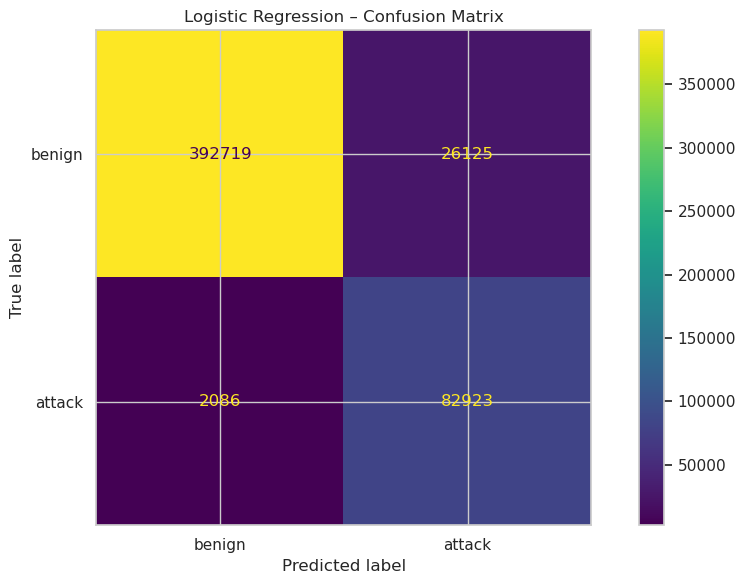

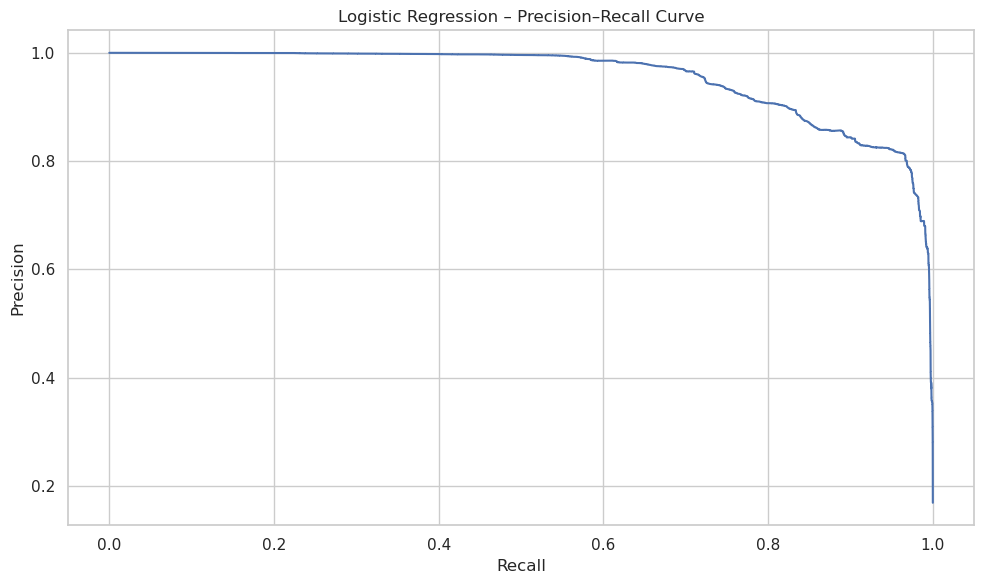

Logistic Regression PR-AUC (test): 0.955


In [60]:
# Confusion matrix – Logistic Regression
cm_lr = confusion_matrix(y_test, y_test_pred)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["benign", "attack"])
disp_lr.plot(values_format="d")
plt.title("Logistic Regression – Confusion Matrix")
plt.tight_layout()
plt.show()

# Precision–Recall curve – Logistic Regression
precision_lr_curve, recall_lr_curve, _ = precision_recall_curve(y_test, y_test_proba)
plt.plot(recall_lr_curve, precision_lr_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Logistic Regression – Precision–Recall Curve")
plt.tight_layout()

os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/logreg_pr_curve.png", bbox_inches="tight")
plt.show()

print(f"Logistic Regression PR-AUC (test): {logreg_pr_auc:.3f}")

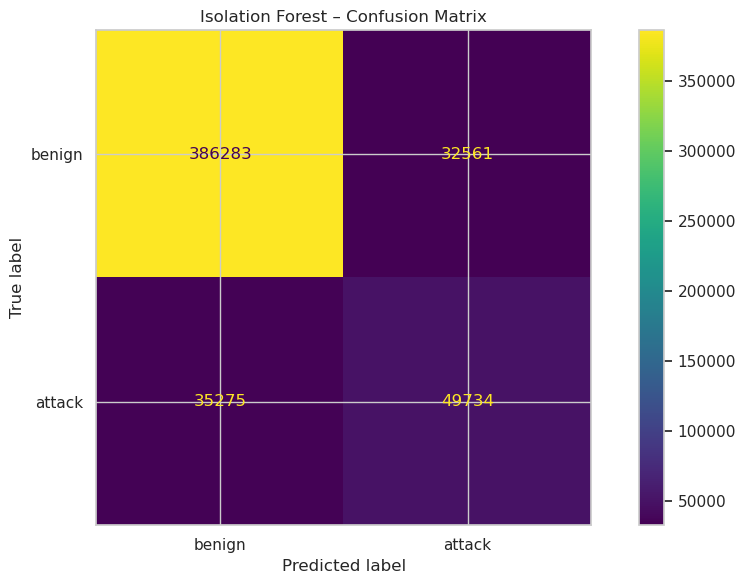

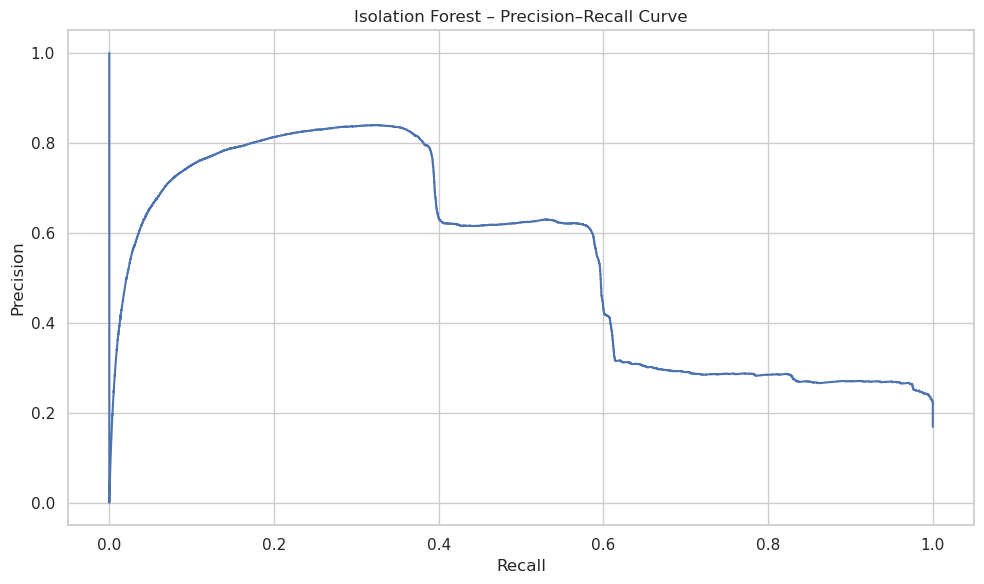

Isolation Forest PR-AUC (test): 0.540


In [61]:
# Confusion matrix – Isolation Forest
cm_iso = confusion_matrix(y_test, iso_y_pred)
disp_iso = ConfusionMatrixDisplay(confusion_matrix=cm_iso, display_labels=["benign", "attack"])
disp_iso.plot(values_format="d")
plt.title("Isolation Forest – Confusion Matrix")
plt.tight_layout()
plt.show()

# Precision–Recall curve – Isolation Forest
precision_iso_curve, recall_iso_curve, _ = precision_recall_curve(y_test, iso_scores)
plt.plot(recall_iso_curve, precision_iso_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Isolation Forest – Precision–Recall Curve")
plt.tight_layout()
os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/iso_forest_pr_curve.png", bbox_inches="tight")
plt.show()

print(f"Isolation Forest PR-AUC (test): {iso_pr_auc:.3f}")

**Security-oriented interpretation**

- **Logistic Regression**: a strong first-pass detector for the attack families it has seen.
  - At the default threshold it catches ~98% of attacks overall, but ~24% of its alerts are
    false positives (precision ≈ 0.76) — threshold tuning or a second-stage classifier is needed
    before feeding a SOC queue.
  - The per-attack breakdown matters operationally: web attacks (XSS, brute force, SQLi) and Bot
    C2 traffic are mostly missed — coverage for those must come from other controls
    (WAF, EDR, egress monitoring), not this model.
  - The cross-day drop (0.955 → 0.72–0.81) is the realistic expectation for novel attack
    behavior.

- **Isolation Forest**: a *supplementary* anomaly score, not a standalone detector.
  - At natural prevalence its ranking quality is modest (PR-AUC ≈ 0.54 vs no-skill 0.169).
  - Most useful as an additional feature for downstream models or as a low-priority anomaly
    feed, since it requires no labels and can in principle surface novel behavior.